In [1]:
import numpy as np
import pandas as pd
import astropy.units as u

from astropy.coordinates import cartesian_to_spherical, SkyCoord, Galactocentric
from numpy.polynomial import Polynomial as P

In [2]:
# import funcs

%run ./utils.ipynb

In [3]:
source = '/cosma5/data/durham/dc-pick2/simulations'

In [63]:
hyades_path = source + '/Hyades'
times = [300]

step, glob_df, Myr_per_Nbody = get_steps_at_times(hyades_path, times)
step_df = step[300]

/tmp/ipykernel_1100416/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


In [5]:
step_df

,M,NAM,POT,Vx,Vy,Vz,X,Y,Z
0,0.017380,3096,-0.150068,2.873971,0.567792,0.757047,-1043.450073,537.539734,-16.143837
1,0.089583,4377,-0.146794,2.091799,0.682195,1.224897,-1043.888916,535.934204,-18.068363
2,0.012537,7398,-0.145626,2.255207,1.601812,1.072176,-1043.901855,538.349304,-16.412458
3,1.191852,2738,-0.148580,1.760767,0.470834,0.936493,-1043.205566,537.677734,-16.326563
4,0.054072,2241,-0.155790,1.981243,1.626340,1.106368,-1043.612305,538.055542,-15.968308
...,...,...,...,...,...,...,...,...,...
8449,0.012893,7451,-0.058077,2.000656,0.766159,0.818289,-1037.283203,508.142303,-13.125261
8450,0.478688,7161,-0.059400,1.543559,0.778369,1.457630,-1018.890076,551.872253,-17.456345
8451,0.325312,7047,-0.035527,1.356145,2.190726,0.645631,-1076.270264,595.098755,-23.703798
8452,0.081077,1870,-0.089244,1.834443,0.836257,0.078898,-1040.456909,545.337524,-29.844770


In [64]:
gc = SkyCoord(
    x=step_df["X"].values * u.pc,
    y=step_df["Y"].values * u.pc,
    z=step_df["Z"].values * u.pc,
    v_x=step_df["Vx"].values * (u.km/u.s),
    v_y=step_df["Vy"].values * (u.km/u.s),
    v_z=step_df["Vz"].values * (u.km/u.s),
    frame=Galactocentric()
)

icrs = gc.icrs
step_df["ra"] = icrs.ra.deg
step_df["dec"] = icrs.dec.deg
step_df["dist"] = icrs.distance.to(u.pc).value

In [23]:
icrs.velocity

<CartesianDifferential (d_x, d_y, d_z) in km / s
    [(-114.40803963, 119.13488263, -181.40646708),
     (-114.71272293, 119.67594129, -180.72957115),
     (-114.13517191, 119.15396933, -180.19133225), ...,
     (-113.42281337, 119.76126632, -179.51250395),
     (-113.62772598, 120.05675773, -181.01424865),
     (-111.53646799, 120.85354981, -181.2512231 )]>

In [75]:
# finding rotation between average ra dec velocity and x axis - https://stackoverflow.com/questions/6247153/angle-from-2d-unit-vector
pmra_mean = np.median(icrs.pm_ra_cosdec.to_value())
pmdec_mean = np.median(icrs.pm_dec.to_value())

theta = np.arctan2(pmdec_mean, pmra_mean) * u.rad
theta = theta.to(u.deg)
theta

<Quantity -119.1865423 deg>

In [55]:
step_df

,M,NAM,POT,Vx,Vy,Vz,X,Y,Z,ra,dec,dist
0,0.017380,3096,-0.150068,2.873971,0.567792,0.757047,-1043.450073,537.539734,-16.143837,269.049335,-25.283091,7099.000340
1,0.089583,4377,-0.146794,2.091799,0.682195,1.224897,-1043.888916,535.934204,-18.068363,269.057162,-25.301854,7098.451641
2,0.012537,7398,-0.145626,2.255207,1.601812,1.072176,-1043.901855,538.349304,-16.412458,269.055202,-25.278321,7098.612614
3,1.191852,2738,-0.148580,1.760767,0.470834,0.936493,-1043.205566,537.677734,-16.326563,269.051269,-25.282997,7099.255545
4,0.054072,2241,-0.155790,1.981243,1.626340,1.106368,-1043.612305,538.055542,-15.968308,269.050351,-25.278708,7098.876741
...,...,...,...,...,...,...,...,...,...,...,...,...
8449,0.012893,7451,-0.058077,2.000656,0.766159,0.818289,-1037.283203,508.142303,-13.125261,268.891966,-25.478261,7102.970803
8450,0.478688,7161,-0.059400,1.543559,0.778369,1.457630,-1018.890076,551.872253,-17.456345,269.113994,-25.201455,7124.592533
8451,0.325312,7047,-0.035527,1.356145,2.190726,0.645631,-1076.270264,595.098755,-23.703798,269.378002,-24.894858,7070.930301
8452,0.081077,1870,-0.089244,1.834443,0.836257,0.078898,-1040.456909,545.337524,-29.844770,269.188710,-25.285943,7102.663813


In [17]:
icrs

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(269.04933464, -25.28309104, 7099.00033952),
     (269.0571621 , -25.3018543 , 7098.45164128),
     (269.05520186, -25.27832099, 7098.61261447), ...,
     (269.37800232, -24.89485765, 7070.93030117),
     (269.1887101 , -25.2859425 , 7102.66381284),
     (270.11628103, -25.48250781, 7067.60642903)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-3.4579471 , -6.36185665, -28.514518  ),
     (-3.46705629, -6.35144878, -29.23262879),
     (-3.44968089, -6.32993162, -29.08332353), ...,
     (-3.422369  , -6.34630715, -31.94340992),
     (-3.42489911, -6.36350515, -29.77048652),
     (-3.32174368, -6.43841609, -31.3199161 )]>

In [66]:
centre_deg = SkyCoord(ra=np.median(step_df['ra']) * u.deg,
                  dec=np.median(step_df['dec']) * u.deg,
                  frame='icrs')

sky_deg = SkyCoord(ra=step_df['ra'].values * u.deg,
                   dec=step_df['dec'].values * u.deg,
                   frame='icrs')
                               
tp = sky_deg.transform_to(centre_deg.skyoffset_frame(rotation=-theta))

step_df["x_deg"] = tp.lon.deg
step_df["y_deg"] = tp.lat.deg

In [68]:
density_filter=20
bins=100

xmin, xmax = np.percentile(step_df["x_deg"], [.5,99.5])
ymin, ymax = np.percentile(step_df["y_deg"], [.5,99.5])

mass_grid, xedges, yedges = np.histogram2d(step_df["x_deg"], step_df["y_deg"]
                                           ,bins=bins,weights=step_df['M'],
                                          range=[[xmin, xmax], [ymin, ymax]])


dx = xedges[1] - xedges[0]
dy = yedges[1] - yedges[0]


density = mass_grid / (dx * dy)

mask = density > density_filter

masked_density = density.copy()
masked_density[~mask] = 0

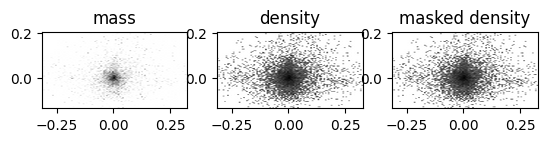

In [69]:
fig, ax = plt.subplots(1,3)
ax[0].imshow(
        np.log10(mass_grid.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax[0].set_title('mass')
ax[1].imshow(
        np.log10(density.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax[1].set_title('density')
ax[2].imshow(
        np.log10(masked_density.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax[2].set_title('masked density')

#ax.set_xlim([-offset,offset])
#ax.set_ylim([-offset,offset])

plt.show()

In [70]:
ridge_x = []
ridge_y = []
ridge_w = []

xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2

for i in range(density.shape[0]):
    col = density[i, :]

    j = np.argmax(col)

    if col[j] < density_filter:
        continue

    ridge_x.append(xc[i])
    ridge_y.append(yc[j])
    ridge_w.append(col[j])

ridge_x = np.array(ridge_x)
ridge_y = np.array(ridge_y)
ridge_w = np.array(ridge_w)


coeffs = np.polyfit(ridge_x, ridge_y, w=ridge_w, deg=4)
coeffs

array([-1.01053913e+01,  2.24612212e+00,  9.81569498e-01, -8.29671644e-02,
       -3.38648980e-03])

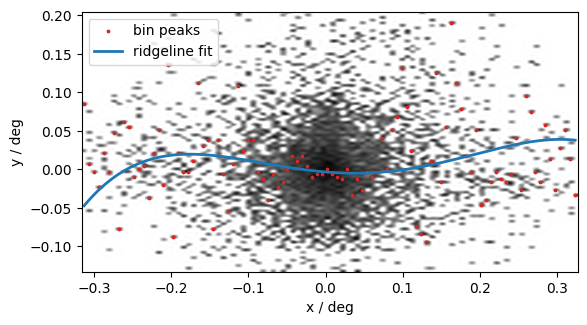

In [71]:
x_fit = np.linspace(ridge_x.min(), ridge_x.max(), 500)
y_fit = np.polyval(coeffs, x_fit)

fig, ax = plt.subplots()
ax.imshow(
        np.log10(masked_density.T + 1),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='gray_r',
        interpolation='spline36'
    )
ax.scatter(ridge_x, ridge_y, s=3, label="bin peaks", color='tab:red')
ax.plot(x_fit, y_fit, color="tab:blue", linewidth=2, label="ridgeline fit")


ax.set_aspect("equal")
plt.legend()
ax.set_xlabel("x / deg")
ax.set_ylabel("y / deg")
plt.show()